In [1]:
import glob
import os
import matplotlib
from matplotlib import pyplot as plt
from sklearn import svm # scikit-learn
import seaborn as sns # for nice visualizations
import pandas as pd # for loading the data from csv
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn import svm

# Data Preparation

In [2]:
dfs = []
for path in glob.glob('shared_data/**/*.csv', recursive=True):
    parts = os.path.basename(path).replace('.csv', "").split('-')
    df = pd.read_csv(path)
    df['person']    = parts[0]
    df['activity']  = parts[1]
    df['frequency'] = parts[2]
    df['placement'] = parts[3]
    df['trial']     = int(parts[4])
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)
df.head()

(510243, 13)


,id,timestamp,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,person,activity,frequency,placement,trial
0,1,1.778591e+09,3.127838,-3.462684,-0.724850,1.678857,-2.765959,-5.057343,daniel,jumpingjacks,100Hz,hand,1
1,2,1.778591e+09,3.059746,-3.413873,-1.105091,1.678857,-2.765959,-5.057343,daniel,jumpingjacks,100Hz,hand,1
2,3,1.778591e+09,1.407966,-3.197394,-1.922439,2.915629,-0.991229,-7.732222,daniel,jumpingjacks,100Hz,hand,1
3,4,1.778591e+09,-0.186704,-2.953337,-1.360131,1.057808,-1.102549,-8.827314,daniel,jumpingjacks,100Hz,hand,1
4,5,1.778591e+09,-0.186704,-2.953337,-1.360131,1.057808,-1.102549,-8.827314,daniel,jumpingjacks,100Hz,hand,1


In [3]:
df['person'] = df['person'].str.lower()
df['activity'] = df['activity'].str.lower()
df['placement'] = df['placement'].str.lower()

In [4]:
df['person'].value_counts()

person
ferdi         48040
vanessa       48040
maximilian    48005
marcel        48002
patrick       48000
lennart       48000
martina       47998
felix         47984
georg         47949
thu           41771
daniel        35454
susi           1000
Name: count, dtype: int64

# Data Preprocessing

In [5]:
#df = df[df['person'] != 'susi']  # only one dataset, but improves accuracy
#df = df[df['person'] != 'martina']  # no gyro values

In [6]:
# Deduplicate consecutive identical rows within each recording from felix
sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
felix = df['person'] == 'felix'
df_felix = df[felix].groupby(['activity', 'frequency', 'placement', 'trial'], group_keys=False).apply(
    lambda g: g[(g[sensor_cols] != g[sensor_cols].shift()).any(axis=1)],
    include_groups=False,
)
df = pd.concat([df[~felix], df_felix], ignore_index=True)

In [7]:
df = df[df['person'] != 'felix']

In [8]:
df.groupby('person')['gyro_x'].max()

person
daniel           9.540508
ferdi           19.591824
georg           11.147519
lennart        399.960000
marcel          14.213613
martina          0.000000
maximilian    1262.820000
patrick          9.649067
susi             7.788947
thu             12.005173
vanessa         12.594820
Name: gyro_x, dtype: float64

In [9]:
m5stack = ['felix', 'lennart', 'maximilian']
df.loc[df['person'].isin(m5stack), ['gyro_x', 'gyro_y', 'gyro_z']] /= 180/np.pi

In [10]:
df.groupby('person')['gyro_x'].apply(lambda x: x.abs().max())

person
daniel        10.488594
ferdi         21.292930
georg         13.684593
lennart        9.290213
marcel        14.213613
martina        0.000000
maximilian    34.906585
patrick        9.964579
susi          10.378872
thu           18.177504
vanessa       12.594820
Name: gyro_x, dtype: float64

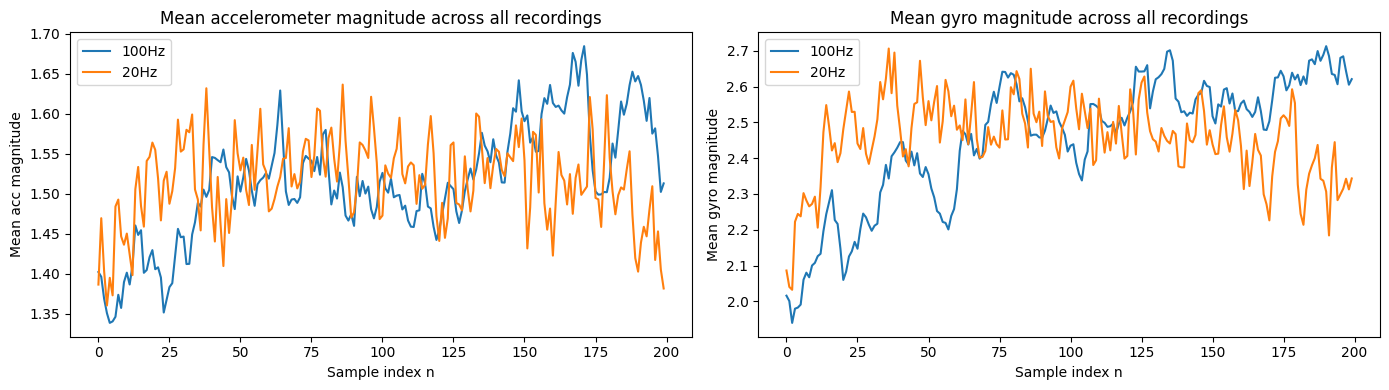

In [11]:
df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
df['gyro_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)
df['sample_idx'] = df.groupby(['person', 'activity', 'frequency', 'placement', 'trial']).cumcount()

mean_by_freq = df.groupby(['frequency', 'sample_idx'])[['acc_mag', 'gyro_mag']].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for freq, group in mean_by_freq.groupby('frequency'):
    ax1.plot(group['sample_idx'][:200], group['acc_mag'][:200], label=freq)
    ax2.plot(group['sample_idx'][:200], group['gyro_mag'][:200], label=freq)

ax1.set_xlabel('Sample index n')
ax1.set_ylabel('Mean acc magnitude')
ax1.set_title('Mean accelerometer magnitude across all recordings')
ax1.legend()

ax2.set_xlabel('Sample index n')
ax2.set_ylabel('Mean gyro magnitude')
ax2.set_title('Mean gyro magnitude across all recordings')
ax2.legend()

plt.tight_layout()
plt.show()

## Windowing and Input Parameters

In [20]:
'''
COLS = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
WIN, STEP = 255, 125  # 2.55s at 100Hz
TRIM = 0
PLACEMENT = 'hand'  # or 'hand'
rows = []
for (person, activity, placement, trial), g in df[(df['frequency']=='100Hz') & (df['placement']==PLACEMENT)].groupby(['person','activity','placement','trial']):
    g = g.reset_index(drop=True)
    for s in range(TRIM, len(g) - WIN + 1, STEP):
        w = g.iloc[s:s+WIN][COLS].values.T
        freqs = np.fft.rfftfreq(WIN, d=1/100)
        #fft_mag = np.abs(np.fft.rfft(w, axis=1))
        fft_mag = np.abs(np.fft.rfft(w * np.hamming(WIN), axis=1))
        dominant_freq = freqs[fft_mag[:, 1:].argmax(axis=1) + 1]  # skip DC component
        rows.append([
            *w.mean(1),
            *w.std(1),
            *np.ptp(w, axis=1),
            *[(np.diff(np.sign(r)) != 0).sum() / len(r) for r in w],
            *np.sqrt((w[3:]**2).mean(1)),
            *dominant_freq,
            activity,
            person,
        ])
windows = pd.DataFrame(rows)
feat_names = [f'{f}_{c}' for f in ['mean','std','range','zcr'] for c in COLS] + \
             ['rms_gyro_x', 'rms_gyro_y', 'rms_gyro_z'] + \
             [f'domfreq_{c}' for c in COLS]
windows.columns = feat_names + ['activity', 'person']
print(windows.shape)
'''

"\nCOLS = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']\nWIN, STEP = 255, 125  # 2.55s at 100Hz\nTRIM = 0\nPLACEMENT = 'hand'  # or 'hand'\nrows = []\nfor (person, activity, placement, trial), g in df[(df['frequency']=='100Hz') & (df['placement']==PLACEMENT)].groupby(['person','activity','placement','trial']):\n    g = g.reset_index(drop=True)\n    for s in range(TRIM, len(g) - WIN + 1, STEP):\n        w = g.iloc[s:s+WIN][COLS].values.T\n        freqs = np.fft.rfftfreq(WIN, d=1/100)\n        fft_mag = np.abs(np.fft.rfft(w * np.hamming(WIN), axis=1))\n        dominant_freq = freqs[fft_mag[:, 1:].argmax(axis=1) + 1]  # skip DC component\n        rows.append([\n            *w.mean(1),\n            *w.std(1),\n            *np.ptp(w, axis=1),\n            *[(np.diff(np.sign(r)) != 0).sum() / len(r) for r in w],\n            *np.sqrt((w[3:]**2).mean(1)),\n            *dominant_freq,\n            activity,\n            person,\n        ])\nwindows = pd.DataFrame(rows)\nfeat_names 

In [28]:
# 20 Hz

COLS = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
WIN, STEP = 51, 25  # 2.56s at 20Hz
TRIM = 0
PLACEMENT = 'hand'  # or 'hand'

rows = []
for (person, activity, placement, trial), g in df[(df['frequency']=='20Hz') & (df['placement']==PLACEMENT)].groupby(['person','activity','placement','trial']):
    g = g.reset_index(drop=True)
    for s in range(TRIM, len(g) - WIN + 1, STEP):
        w = g.iloc[s:s+WIN][COLS].values.T
        freqs = np.fft.rfftfreq(WIN, d=1/20)
        fft_mag = np.abs(np.fft.rfft(w, axis=1))
        #fft_mag = np.abs(np.fft.rfft(w * np.hamming(WIN), axis=1))
        dominant_freq = freqs[fft_mag[:, 1:].argmax(axis=1) + 1]  # skip DC component
        rows.append([
            *w.mean(1),
            *w.std(1),
            *np.ptp(w, axis=1),  # peak-to-peak range
            *[(np.diff(np.sign(r)) != 0).sum() / len(r) for r in w],  # zero crossing rate
            *np.sqrt((w[3:]**2).mean(1)),  # root mean square (RMS) energy
            *dominant_freq,
            activity,
            person,
        ])

windows = pd.DataFrame(rows)
feat_names = [f'{f}_{c}' for f in ['mean','std','range','zcr'] for c in COLS] + \
             ['rms_gyro_x', 'rms_gyro_y', 'rms_gyro_z'] + \
             [f'domfreq_{c}' for c in COLS]
windows.columns = feat_names + ['activity', 'person']
print(windows.shape)


(1316, 35)


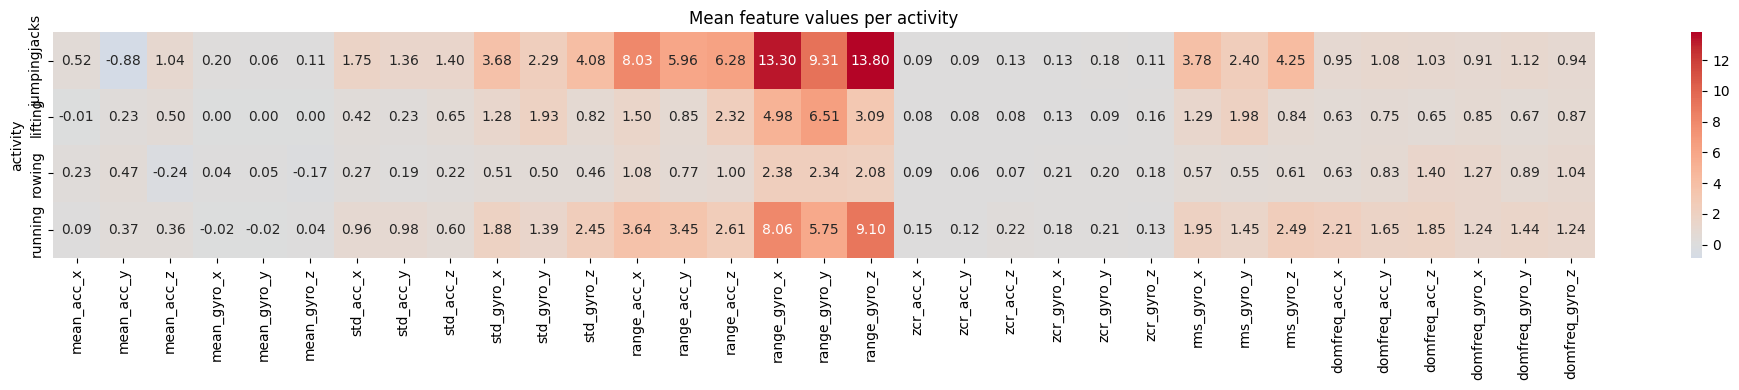

In [29]:
plt.figure(figsize=(20, 4))
sns.heatmap(windows.groupby('activity')[feat_names].mean(), 
            cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Mean feature values per activity')
plt.tight_layout()
plt.show()

# Training

In [30]:
test_persons = ['georg', 'patrick']
#test_persons = ['maximilian', 'patrick']
train = windows[~windows['person'].isin(test_persons)]
test  = windows[ windows['person'].isin(test_persons)]

X_train = train[feat_names].astype(float)
y_train = train['activity']
X_test  = test[feat_names].astype(float)
y_test  = test['activity']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [31]:
for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:
    clf = svm.SVC(kernel=kernel)
    clf.fit(X_train, y_train)
    print(kernel, clf.score(X_test, y_test))

linear 0.8625
rbf 0.7875
poly 0.7041666666666667
sigmoid 0.7666666666666667


In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC()),
])

param_grid = [
    {'svc__kernel': ['linear'],  'svc__C': [0.1, 1, 10, 100]},
    {'svc__kernel': ['rbf'],     'svc__C': [0.1, 1, 10, 100], 'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1]},
    {'svc__kernel': ['poly'],    'svc__C': [0.1, 1, 10],      'svc__gamma': ['scale', 0.01, 0.1], 'svc__degree': [2, 3, 4], 'svc__coef0': [0.0, 0.5, 1.0]},
    {'svc__kernel': ['sigmoid'], 'svc__C': [0.1, 1, 10],      'svc__gamma': ['scale', 0.01, 0.1], 'svc__coef0': [0.0, 0.5, 1.0]},
]

grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print(grid.best_params_, grid.score(X_test, y_test))

{'svc__C': 0.1, 'svc__coef0': 0.5, 'svc__degree': 3, 'svc__gamma': 0.1, 'svc__kernel': 'poly'} 0.7916666666666666


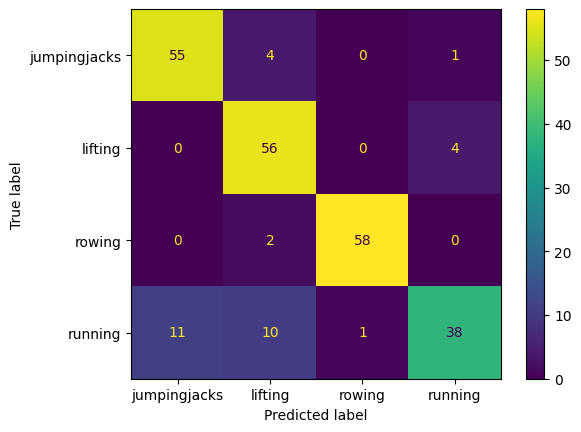

In [33]:
clf = svm.SVC(kernel='linear')
clf.fit(X_train, y_train)

ConfusionMatrixDisplay(confusion_matrix(y_test, clf.predict(X_test)), display_labels=clf.classes_).plot()

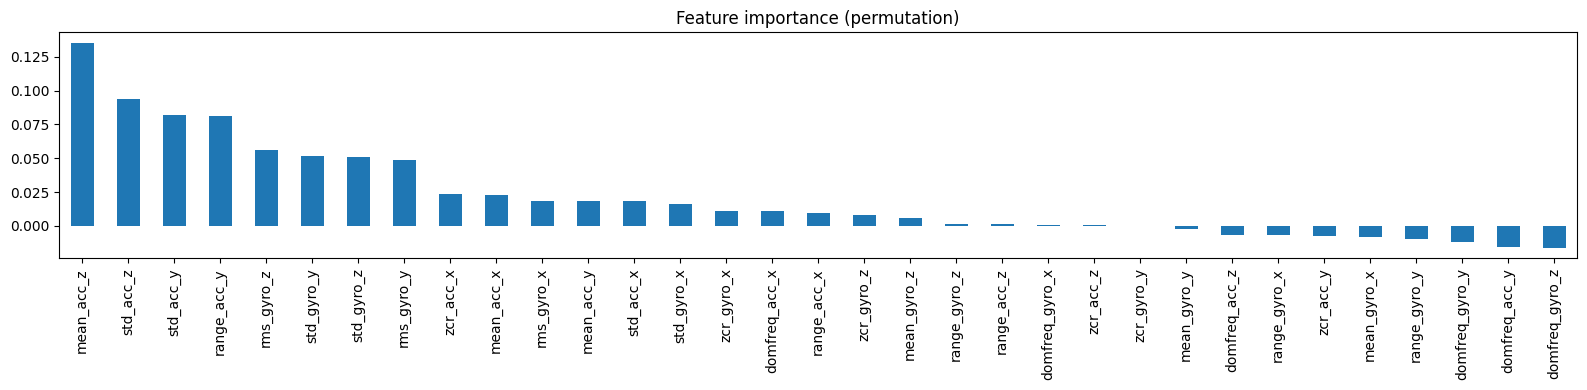

In [34]:
clf = svm.SVC(kernel='linear')
clf.fit(X_train, y_train)

result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)

importances = pd.Series(result.importances_mean, index=feat_names).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(16, 4), title='Feature importance (permutation)')
plt.tight_layout()
plt.show()